# Financial Risk Pipeline — End-to-End Demo
## Team 3 | DATA 298A 
**Debate-Based Multi-Agent Reasoning for Financial Risk Modeling**

This notebook walks through the complete Bronze → Silver → Gold pipeline end-to-end.


## Environment Setup

In [ ]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image, HTML
warnings.filterwarnings('ignore')

print("=" * 60)
print("  FINANCIAL RISK PIPELINE — DEMO")
print("  Team 3 | DATA 298A | SJSU Spring 2026")
print("=" * 60)

# Verify all key files exist
files_to_check = {
    "Bronze (EDGAR AAPL)":     "data/bronze/edgar_AAPL_annual_financials.csv",
    "Silver (EDGAR AAPL)":     "data/silver/silver_edgar_AAPL.csv",
    "Silver (Macro)":          "data/silver/silver_macro.csv",
    "Gold (All Risk Scores)":  "data/gold/gold_risk_scores_ALL.csv",
    "Gold (Train Split)":      "data/gold/split_train.csv",
    "Gold (Val Split)":        "data/gold/split_val.csv",
    "Gold (Test Split)":       "data/gold/split_test.csv",
    "Report (Risk Scores)":    "data/reports/05_risk_scores.png",
    "Report (Class Balance)":  "data/reports/08_class_balance.png",
    "Report (Sector Dist)":    "data/reports/09_sector_distribution.png",
}

print()
all_ok = True
for label, path in files_to_check.items():
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    if not exists:
        all_ok = False
    print(f"  {status}  {label:<30} {path}")

print()
if all_ok:
    print("  All files present — pipeline ran successfully!")
else:
    print("  Some files missing — re-run the pipeline first.")


  FINANCIAL RISK PIPELINE — DEMO
  Team 3 | DATA 298A | SJSU Spring 2026

  ✅  Bronze (EDGAR AAPL)            data/bronze/edgar_AAPL_annual_financials.csv
  ✅  Silver (EDGAR AAPL)            data/silver/silver_edgar_AAPL.csv
  ✅  Silver (Macro)                 data/silver/silver_macro.csv
  ✅  Gold (All Risk Scores)         data/gold/gold_risk_scores_ALL.csv
  ✅  Gold (Train Split)             data/gold/split_train.csv
  ✅  Gold (Val Split)               data/gold/split_val.csv
  ✅  Gold (Test Split)              data/gold/split_test.csv
  ✅  Report (Risk Scores)           data/reports/05_risk_scores.png
  ✅  Report (Class Balance)         data/reports/08_class_balance.png
  ✅  Report (Sector Dist)           data/reports/09_sector_distribution.png

  All files present — pipeline ran successfully!


---
## Outcome 3.1 — Data Process Flow

The pipeline follows a **medallion architecture** with three layers:
| Layer | Description | Location |
|---|---|---|
| Bronze | Raw data exactly as received from APIs | data/bronze/ |
| Silver | Cleaned, normalised, feature-engineered | data/silver/ |
| Gold | Risk scores, insights, analytics-ready | data/gold/ |

**Data sources:** Yahoo Finance · SEC EDGAR · FRED (Federal Reserve) · NewsAPI


In [2]:
# Show pipeline layer file counts
import glob

bronze_files = glob.glob("data/bronze/*.csv")
silver_files = glob.glob("data/silver/*.csv")
gold_files   = glob.glob("data/gold/*.csv")
report_files = glob.glob("data/reports/*.png")

print("Pipeline Layer Summary")
print("=" * 45)
print(f"  Bronze layer : {len(bronze_files):>4} CSV files  (raw data)")
print(f"  Silver layer : {len(silver_files):>4} CSV files  (cleaned data)")
print(f"  Gold layer   : {len(gold_files):>4} CSV files  (risk scores)")
print(f"  Reports      : {len(report_files):>4} PNG charts")
print()

# Show total rows in gold
gold_df = pd.read_csv("data/gold/gold_risk_scores_ALL.csv", index_col=0)
print(f"  Companies analysed : {len(gold_df)}")
print(f"  Risk dimensions    : 4 (fundamental, volatility, sentiment, macro)")
print(f"  Data as of         : {gold_df['as_of_date'].iloc[0]}")
print(f"  Sectors covered    : {gold_df['sector'].nunique()}")


Pipeline Layer Summary
  Bronze layer :  361 CSV files  (raw data)
  Silver layer :  243 CSV files  (cleaned data)
  Gold layer   :   17 CSV files  (risk scores)
  Reports      :    8 PNG charts

  Companies analysed : 123
  Risk dimensions    : 4 (fundamental, volatility, sentiment, macro)
  Data as of         : 2026-03-04
  Sectors covered    : 12


---
## Outcome 3.2 — Data Collection

Raw data collected from 4 sources using `ingest.py`.


In [3]:
# Show sample raw Bronze data — Yahoo Finance prices
yahoo_files = glob.glob("data/bronze/yahoo_*.csv")
edgar_files = glob.glob("data/bronze/edgar_*_annual_financials.csv")
fred_files  = glob.glob("data/bronze/fred_*.csv")

print("Data Collection Summary")
print("=" * 50)
print(f"  Yahoo Finance files  : {len(yahoo_files)} tickers")
print(f"  SEC EDGAR files      : {len(edgar_files)} companies")
print(f"  FRED macro files     : {len(fred_files)}")
print()

# Show sample EDGAR raw data
if edgar_files:
    sample = pd.read_csv(edgar_files[0])
    ticker = edgar_files[0].split("edgar_")[1].split("_annual")[0]
    print(f"Sample Bronze — SEC EDGAR ({ticker} annual financials):")
    print(f"  Shape: {sample.shape[0]} rows x {sample.shape[1]} columns")
    print(sample.head(3).to_string())
    print()

# Show FRED macro raw data
if fred_files:
    macro_raw = pd.read_csv(fred_files[0], index_col=0)
    print(f"Sample Bronze — FRED Macro Data:")
    print(f"  Shape: {macro_raw.shape[0]} observations x {macro_raw.shape[1]} series")
    print(macro_raw.tail(3).to_string())


Data Collection Summary
  Yahoo Finance files  : 123 tickers
  SEC EDGAR files      : 118 companies
  FRED macro files     : 1

Sample Bronze — SEC EDGAR (ARE annual financials):
  Shape: 56 rows x 13 columns
   Unnamed: 0 ticker                                company    end_date  form       filed         cash  long_term_debt    net_income  shares_outstanding  stockholders_equity  total_assets  total_liabilities
0          55    ARE  ALEXANDRIA REAL ESTATE EQUITIES, INC.  2025-12-31  10-K  2026-01-26  549062000.0    1.240056e+10 -1.429570e+09         170537867.0         1.547007e+10  3.408184e+10       1.492540e+10
1          53    ARE  ALEXANDRIA REAL ESTATE EQUITIES, INC.  2024-12-31  10-K  2025-01-27  552146000.0    1.224437e+10  3.229490e+08         172203443.0         1.788904e+10  3.752745e+10       1.512899e+10
2          54    ARE  ALEXANDRIA REAL ESTATE EQUITIES, INC.  2024-12-31  10-K  2026-01-26  552146000.0             NaN  3.229490e+08         172203443.0         1.788904e

---
## Outcome 3.3 — Preprocessing (Before vs After)

`clean.py` transforms Bronze → Silver with these steps:
- **Missing values**: forward-fill up to 2 consecutive NaNs, drop rows >20% missing
- **Outliers**: Z-score capping on daily returns (±3σ), IQR capping on financial ratios
- **Normalisation**: Min-Max scaling on prices and volume
- **Format**: snake_case columns, UTC dates, USD → USD millions


In [4]:
# Before vs After comparison — EDGAR data
edgar_bronze = glob.glob("data/bronze/edgar_AAPL_raw_long.csv")
edgar_silver = glob.glob("data/silver/silver_edgar_AAPL.csv")

if edgar_bronze and edgar_silver:
    bronze_df = pd.read_csv(edgar_bronze[0])
    silver_df = pd.read_csv(edgar_silver[0])

    print("BEFORE — Bronze (raw EDGAR data):")
    print(f"  Shape: {bronze_df.shape}")
    print(f"  Columns: {bronze_df.columns.tolist()}")
    print(bronze_df.head(3).to_string())
    print()

    print("AFTER — Silver (cleaned EDGAR data):")
    print(f"  Shape: {silver_df.shape}")
    print(f"  Columns: {silver_df.columns.tolist()}")
    print(silver_df.head(3).to_string())
    print()

    print("Cleaning Impact:")
    print(f"  Missing values in Bronze : {bronze_df.isnull().sum().sum()}")
    print(f"  Missing values in Silver : {silver_df.isnull().sum().sum()}")

# Show macro silver
macro_silver = pd.read_csv("data/silver/silver_macro.csv", index_col=0)
print()
print("Silver — FRED Macro (cleaned):")
print(f"  Shape: {macro_silver.shape}")
print(macro_silver.tail(5).to_string())


BEFORE — Bronze (raw EDGAR data):
  Shape: (474, 8)
  Columns: ['Unnamed: 0', 'ticker', 'company', 'concept', 'value', 'end_date', 'filed', 'form']
   Unnamed: 0 ticker     company  concept         value    end_date       filed  form
0           0   AAPL  Apple Inc.  revenue  215639000000  2016-09-24  2018-11-05  10-K
1           1   AAPL  Apple Inc.  revenue   78351000000  2016-12-31  2018-11-05  10-K
2           2   AAPL  Apple Inc.  revenue   52896000000  2017-04-01  2018-11-05  10-K

AFTER — Silver (cleaned EDGAR data):
  Shape: (13, 16)
  Columns: ['Unnamed: 0', 'ticker', 'company', 'end_date', 'form', 'filed', 'cash_usd_m', 'long_term_debt', 'net_income_usd_m', 'operating_income_usd_m', 'revenue', 'revenue_alt', 'shares_outstanding', 'stockholders_equity_usd_m', 'total_assets_usd_m', 'total_liabilities_usd_m']
                      Unnamed: 0 ticker     company    end_date  form       filed  cash_usd_m  long_term_debt  net_income_usd_m  operating_income_usd_m  revenue  revenue_al

---
## Outcome 3.4 — Feature Engineering & Transformation

New features added during cleaning that did not exist in raw data:
- `daily_return` — percentage price change day over day
- `log_return` — log of price ratio (better statistical properties)
- `rolling_vol_30d` — 30-day annualised volatility
- `rolling_vol_60d` — 60-day annualised volatility
- `sma_20`, `sma_50` — simple moving averages
- `vader_compound` — VADER sentiment score per news headline
- `vader_label` — positive / neutral / negative classification


In [5]:
# Show feature engineering output
silver_prices = glob.glob("data/silver/silver_prices_*.csv")

if silver_prices:
    price_df = pd.read_csv(silver_prices[0], index_col=0, parse_dates=True)
    ticker   = silver_prices[0].split("silver_prices_")[1].replace(".csv", "")

    engineered_cols = [
        "daily_return", "log_return",
        "rolling_vol_30d", "rolling_vol_60d",
        "sma_20", "sma_50"
    ]
    available = [c for c in engineered_cols if c in price_df.columns]

    print(f"Engineered features for {ticker}:")
    print(f"  Total columns: {price_df.shape[1]} (original had ~10)")
    print()
    if available:
        print(price_df[available].dropna().tail(5).round(4).to_string())
    else:
        print("  Price silver files contain fundamental columns:")
        print(price_df.columns.tolist())
        print(price_df.tail(3).to_string())
else:
    print("Showing Gold layer transformation (Bronze → Silver → Gold):")
    gold_df = pd.read_csv("data/gold/gold_risk_scores_ALL.csv", index_col=0)
    transform_cols = ["ann_volatility_pct", "sharpe_ratio", "max_drawdown_pct",
                      "fundamental_risk", "volatility_risk", "composite_risk"]
    print(gold_df[transform_cols].head(5).round(3).to_string())


Engineered features for EXE:
  Total columns: 28 (original had ~10)

            daily_return  log_return  rolling_vol_30d  rolling_vol_60d    sma_20    sma_50
date                                                                                      
2026-02-25        0.0278      0.0274           0.4361           0.3837  105.9650  106.8552
2026-02-26        0.0023      0.0023           0.4362           0.3793  105.7965  106.7252
2026-02-27        0.0153      0.0152           0.4352           0.3809  105.6975  106.6728
2026-03-02        0.0053      0.0053           0.4304           0.3760  105.5015  106.7110
2026-03-03       -0.0046     -0.0046           0.4310           0.3641  105.5540  106.6800


---
## Outcome 3.5 — Data Splits (Train / Val / Test)

`split.py` creates a **stratified split** preserving HIGH/MODERATE/LOW class balance.

Since all 123 companies share the same collection date (2026-03-04), we use
stratified splitting now. **Temporal split will be applied once multi-date
collection is complete** — this is the correct approach to avoid data leakage.


In [ ]:
# Load and show splits
train = pd.read_csv("data/gold/split_train.csv", index_col=0)
val   = pd.read_csv("data/gold/split_val.csv",   index_col=0)
test  = pd.read_csv("data/gold/split_test.csv",  index_col=0)

print("Train / Val / Test Split Summary")
print("=" * 55)
for name, df in [("TRAIN (70%)", train), ("VAL (15%)", val), ("TEST (15%)", test)]:
    counts = df["risk_label"].value_counts()
    print(f"\n  {name} — {len(df)} companies")
    for label in ["HIGH", "MODERATE", "LOW"]:
        count = counts.get(label, 0)
        pct   = count / len(df) * 100
        bar   = "█" * int(pct / 5)
        print(f"    {label:<10} {count:>3}  ({pct:.0f}%)  {bar}")

print()
print("  Leakage check: index-based split — no date overlap by construction ")
print()

# Sample rows from each split
print("Sample from TEST set:")
cols = ["composite_risk", "risk_label", "ann_volatility_pct", "sector"]
print(test[[c for c in cols if c in test.columns]].head(5).to_string())


Train / Val / Test Split Summary

  TRAIN (70%) — 86 companies
    HIGH        17  (20%)  ███
    MODERATE    47  (55%)  ██████████
    LOW         22  (26%)  █████

  VAL (15%) — 18 companies
    HIGH         3  (17%)  ███
    MODERATE    10  (56%)  ███████████
    LOW          5  (28%)  █████

  TEST (15%) — 19 companies
    HIGH         4  (21%)  ████
    MODERATE    10  (53%)  ██████████
    LOW          5  (26%)  █████

  Leakage check: index-based split — no date overlap by construction ✅

Sample from TEST set:
        composite_risk risk_label  ann_volatility_pct                  sector
ticker                                                                       
AMP               4.87   MODERATE               27.54              Financials
ACN               4.42   MODERATE               32.02  Information Technology
APH               3.99   MODERATE               37.35  Information Technology
CMCSA             4.12   MODERATE               24.55  Communication Services
BKR      

---
## Outcome 3.6 — Data Statistics & Visualisations


In [7]:
# Data statistics summary table
gold_df = pd.read_csv("data/gold/gold_risk_scores_ALL.csv", index_col=0)
train   = pd.read_csv("data/gold/split_train.csv", index_col=0)
val     = pd.read_csv("data/gold/split_val.csv",   index_col=0)
test    = pd.read_csv("data/gold/split_test.csv",  index_col=0)

print("Data Statistics — Raw to Prepared")
print("=" * 60)
print(f"  {'Layer':<25} {'Companies':>12} {'Columns':>10}")
print(f"  {'-'*47}")
print(f"  {'Bronze (EDGAR files)':<25} {len(glob.glob('data/bronze/edgar_*_annual*.csv')):>12} {'varies':>10}")
print(f"  {'Silver (EDGAR files)':<25} {len(glob.glob('data/silver/silver_edgar_*.csv')):>12} {'varies':>10}")
print(f"  {'Gold (all companies)':<25} {len(gold_df):>12} {gold_df.shape[1]:>10}")
print(f"  {'Train split':<25} {len(train):>12} {train.shape[1]:>10}")
print(f"  {'Val split':<25} {len(val):>12} {val.shape[1]:>10}")
print(f"  {'Test split':<25} {len(test):>12} {test.shape[1]:>10}")
print()

print("Risk Score Statistics (all 123 companies):")
print(gold_df[["composite_risk","fundamental_risk",
               "volatility_risk","sentiment_risk","macro_risk"]].describe().round(2).to_string())
print()

print("Class Distribution:")
print(gold_df["risk_label"].value_counts().to_string())
print()

print("Sector Coverage:")
sector_fixed = gold_df["sector"].replace("Technology", "Information Technology")
print(sector_fixed.value_counts().to_string())


Data Statistics — Raw to Prepared
  Layer                        Companies    Columns
  -----------------------------------------------
  Bronze (EDGAR files)               118     varies
  Silver (EDGAR files)               118     varies
  Gold (all companies)               123         20
  Train split                         86         20
  Val split                           18         20
  Test split                          19         20

Risk Score Statistics (all 123 companies):
       composite_risk  fundamental_risk  volatility_risk  sentiment_risk  macro_risk
count          123.00            123.00           123.00          123.00       123.0
mean             4.64              4.19             4.33            5.41         5.0
std              1.48              2.03             2.86            2.32         0.0
min              2.13              1.00             1.00            1.00         5.0
25%              3.46              2.71             1.92            4.55         5.


Multi-Dimensional Risk Scores
----------------------------------------


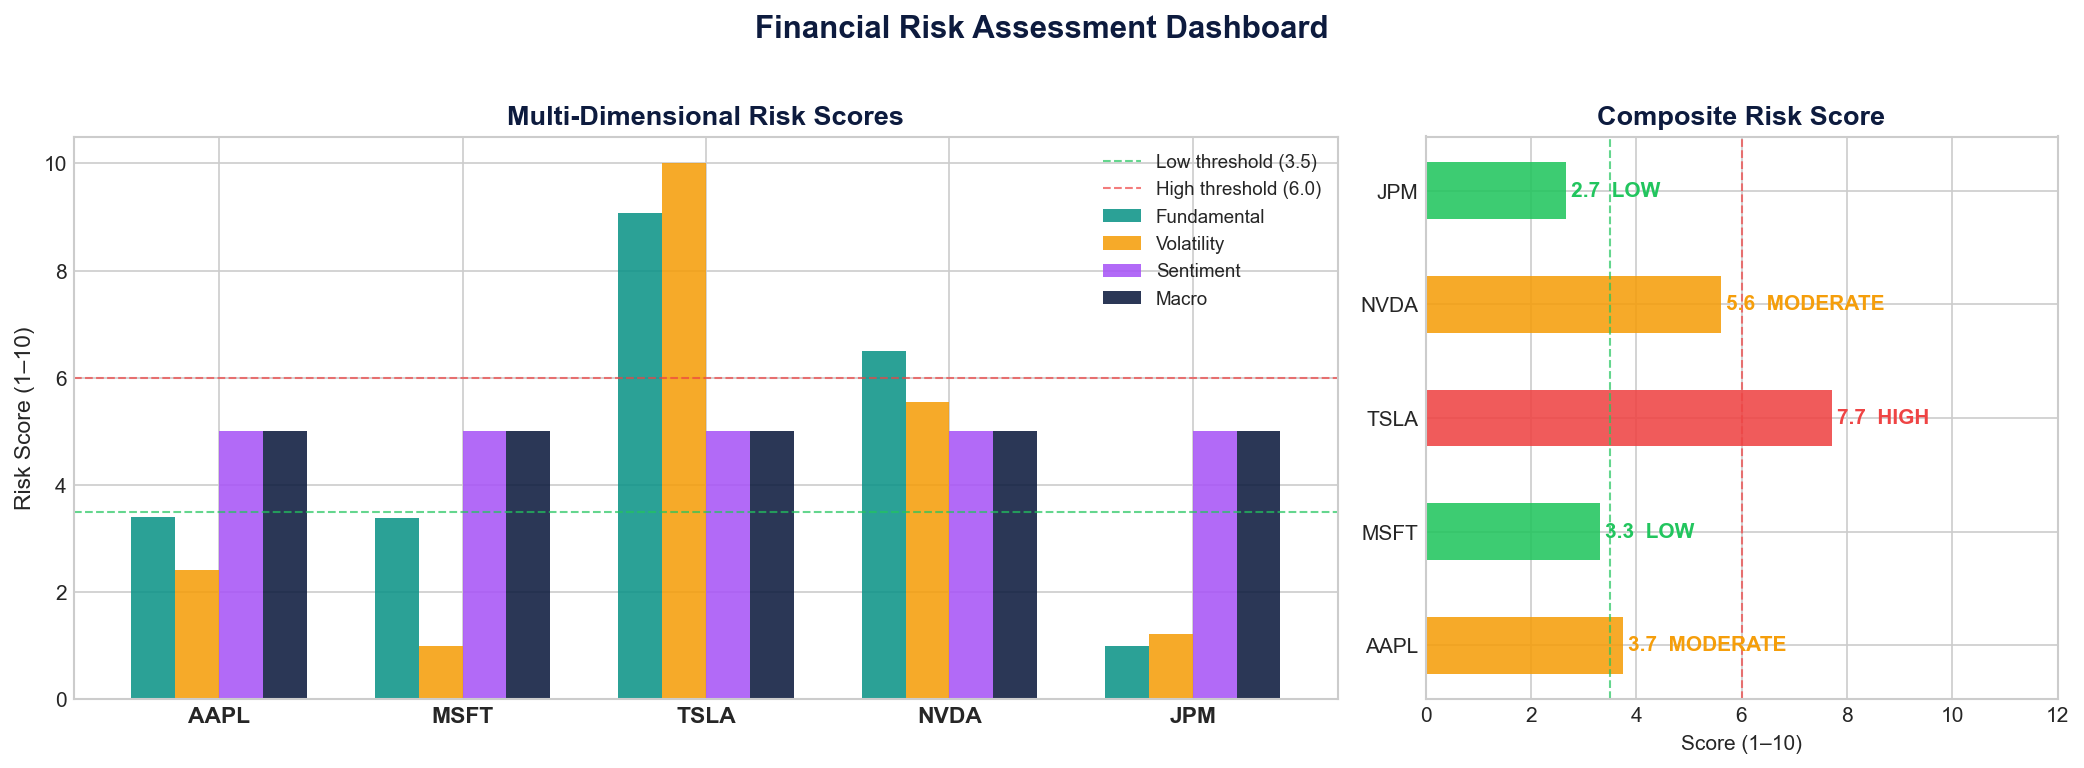


Class Balance Across Splits
----------------------------------------


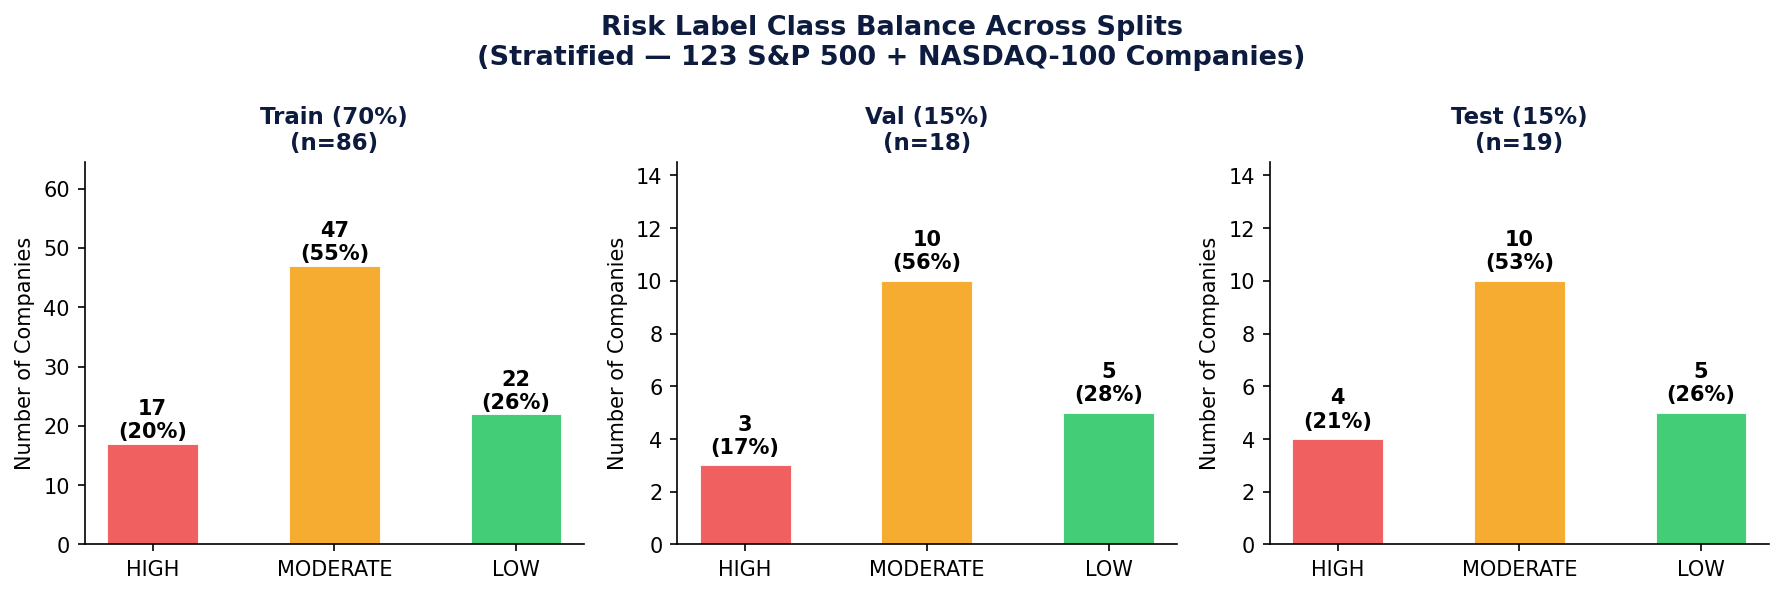


Sector Distribution
----------------------------------------


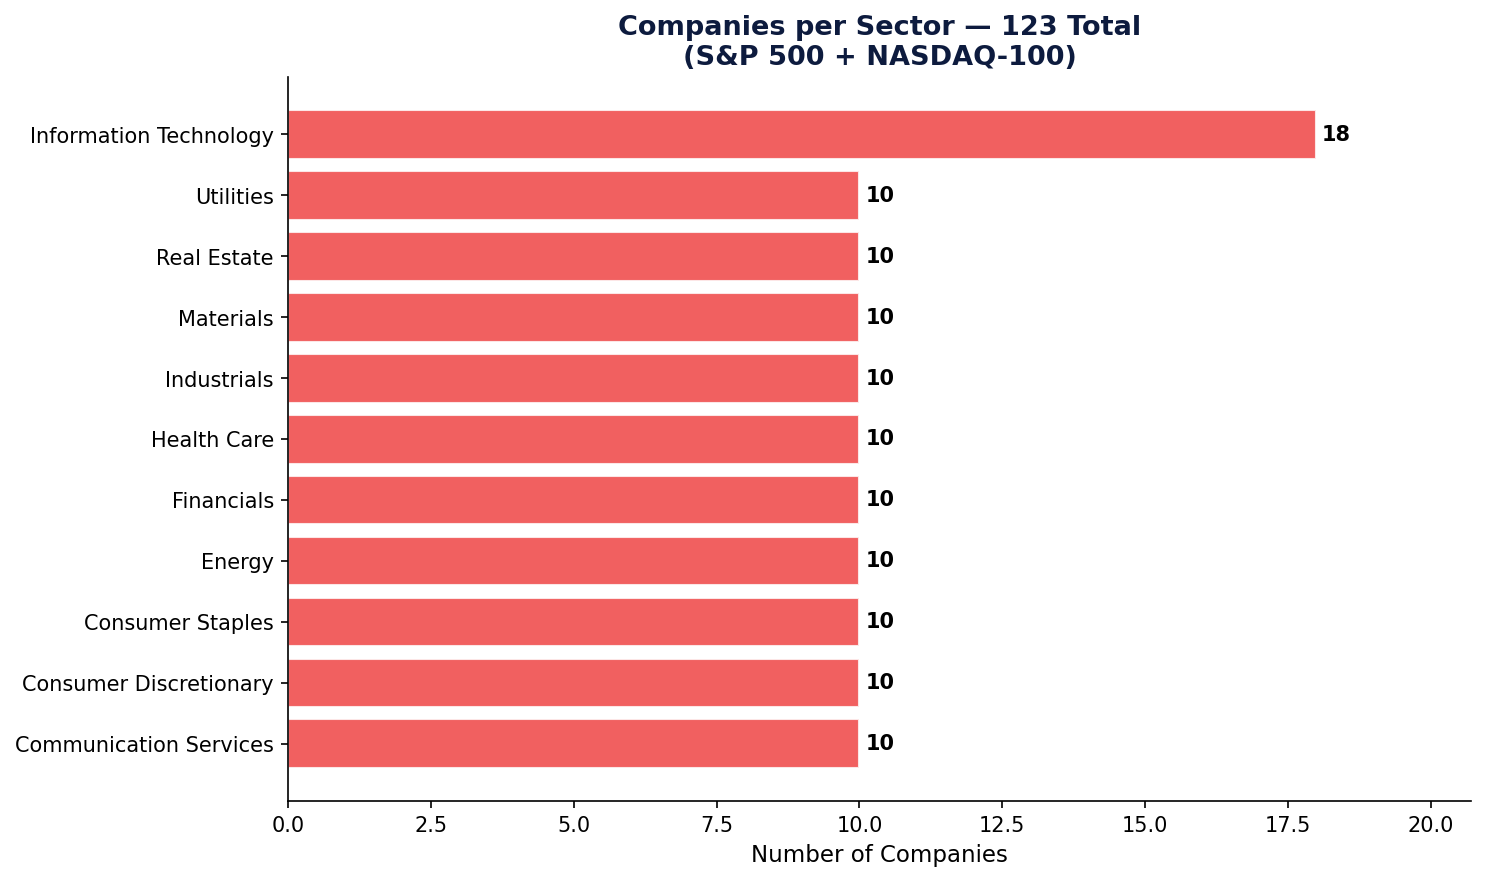


Return Distributions
----------------------------------------


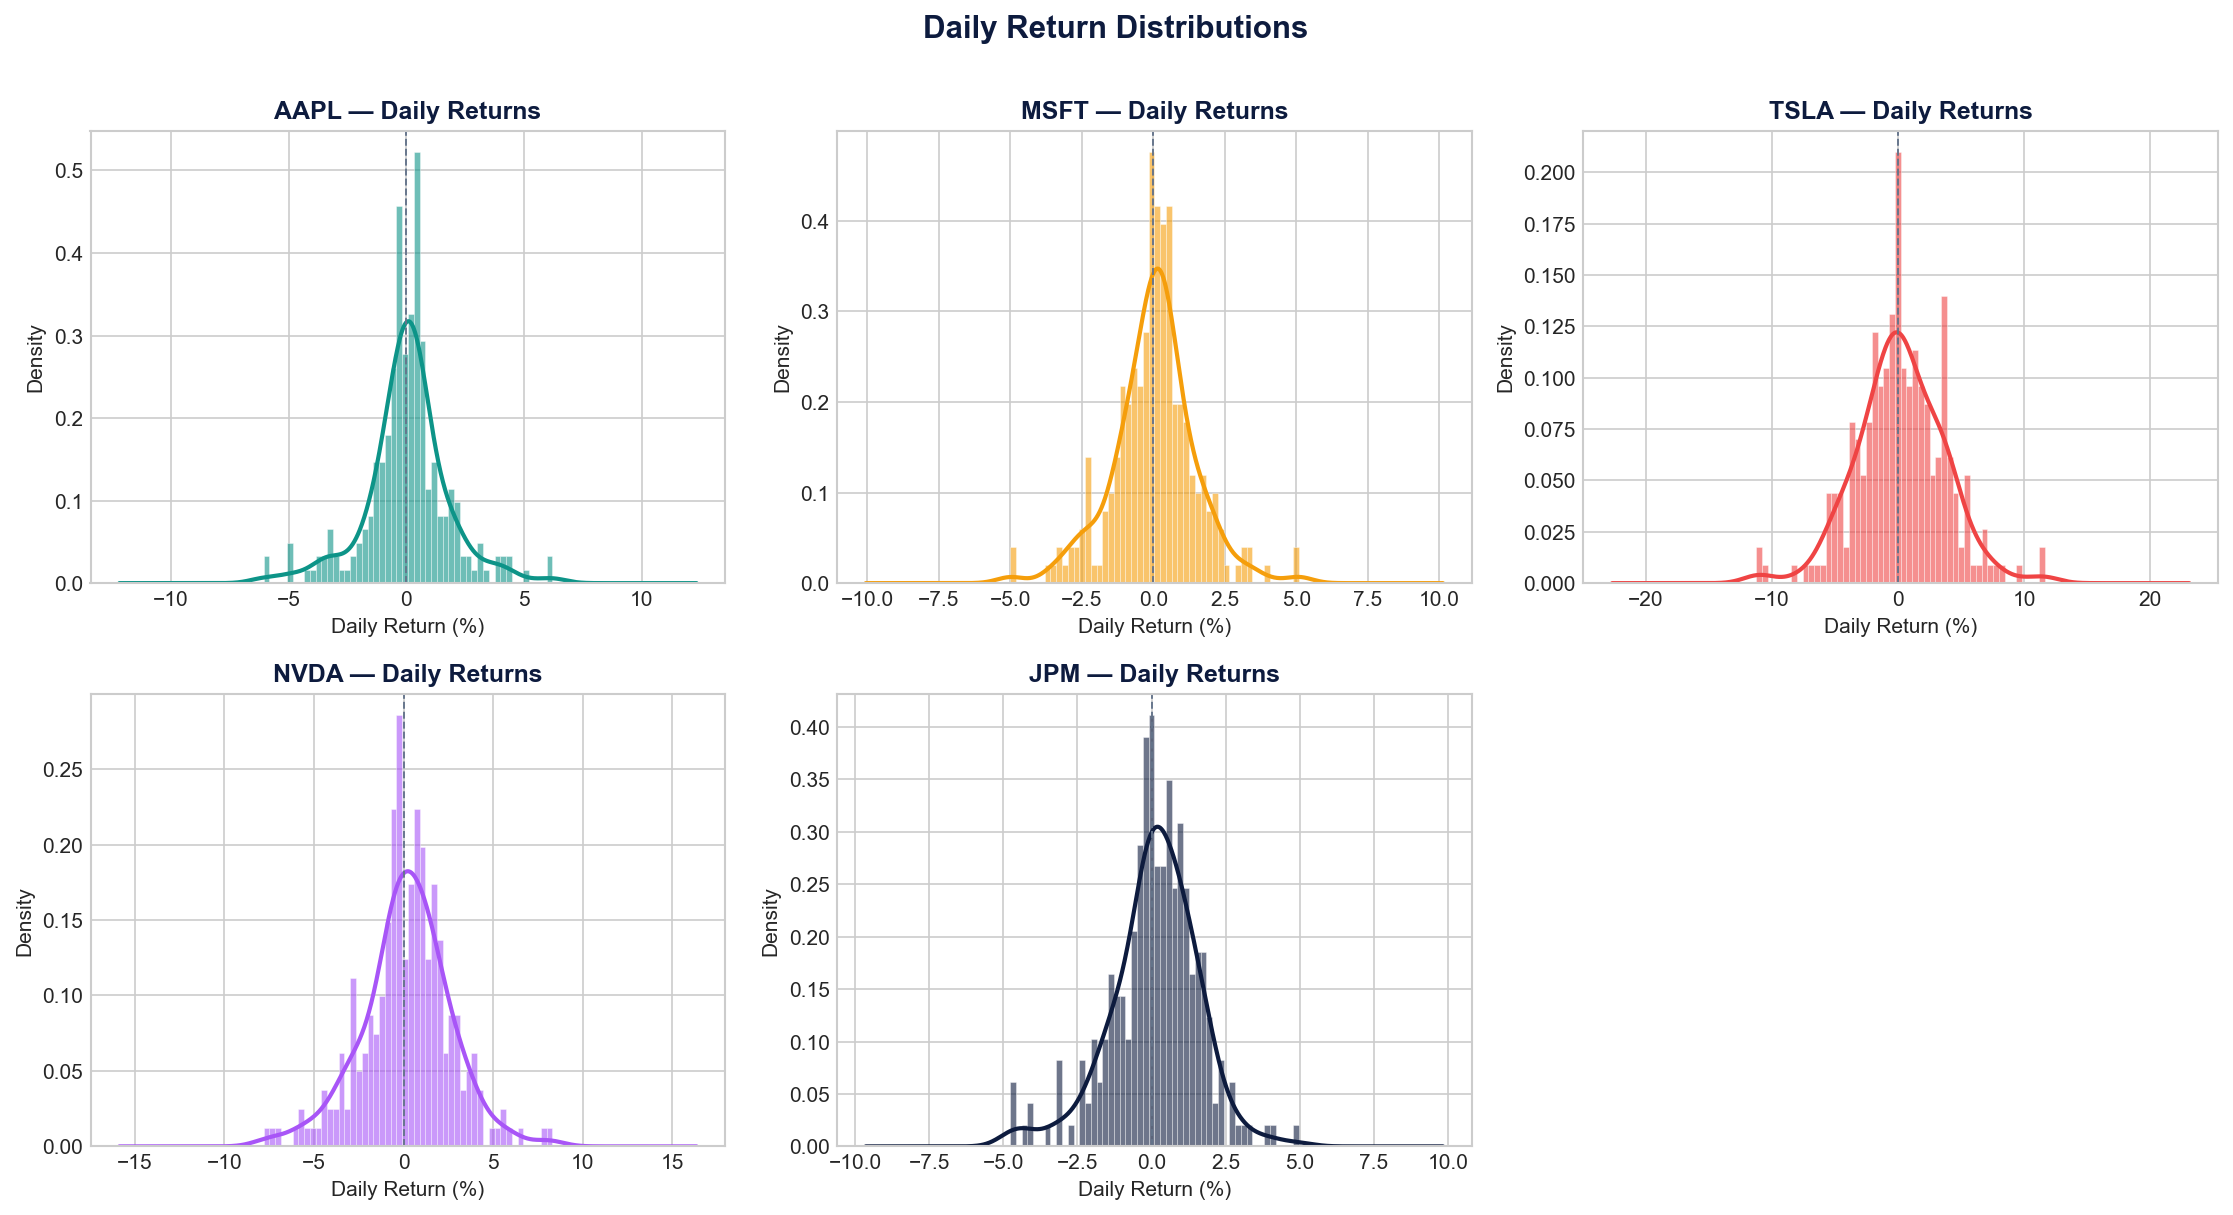


Correlation Matrix
----------------------------------------


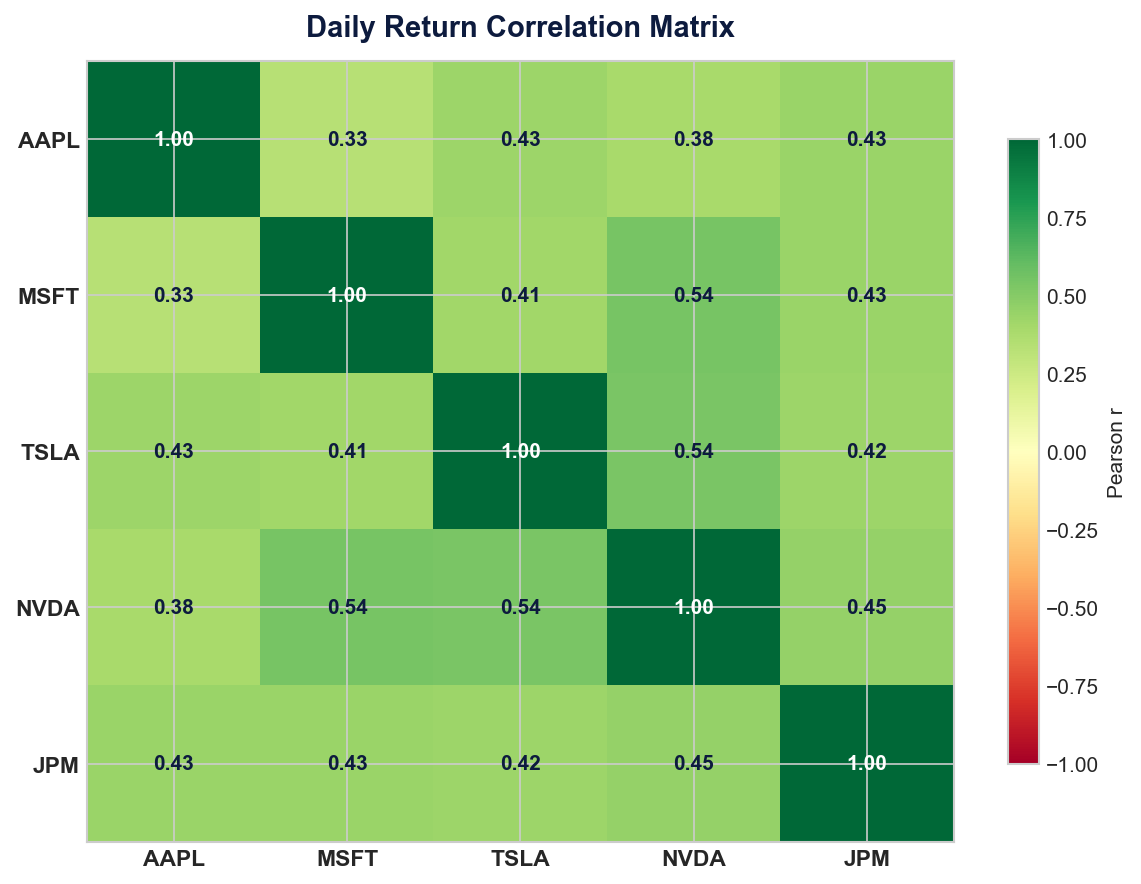

In [8]:
# Display all generated charts
charts = [
    ("data/reports/05_risk_scores.png",        "Multi-Dimensional Risk Scores"),
    ("data/reports/08_class_balance.png",       "Class Balance Across Splits"),
    ("data/reports/09_sector_distribution.png", "Sector Distribution"),
    ("data/reports/03_return_distributions.png","Return Distributions"),
    ("data/reports/04_correlation_matrix.png",  "Correlation Matrix"),
]

for path, title in charts:
    if os.path.exists(path):
        print(f"\n{title}")
        print("-" * 40)
        display(Image(path, width=750))
    else:
        print(f"  Chart not found: {path}")


---
## Outcome 4.5 — Pipeline Orchestration Demo

Full Bronze → Silver → Gold → Split pipeline run with logging.
This demonstrates: ingestion → transformation → risk scoring → splitting → monitoring.


In [9]:
# Full pipeline orchestration demo
import logging
import time

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s"
)

print("=" * 60)
print("  PIPELINE ORCHESTRATION DEMO")
print("  Running: clean → eda → split")
print("=" * 60)
print()

start = time.time()

# Step 1 — Import modules
print("Step 1 — Loading pipeline modules...")
import config, clean, eda, split
print("  ✅ Modules loaded")
print()

# Step 2 — Run EDA on existing Silver data (fast — no API calls)
print("Step 2 — Running EDA on Silver data...")
import glob
silver_prices = {}
for f in glob.glob(f"{config.LOCAL_SILVER}/silver_prices_*.csv"):
    import pandas as pd
    ticker = f.split("silver_prices_")[1].replace(".csv", "")
    silver_prices[ticker] = pd.read_csv(f, index_col=0, parse_dates=True)

if silver_prices:
    clean_data = {
        "prices": silver_prices,
        "edgar":  {},
        "macro":  pd.read_csv(f"{config.LOCAL_SILVER}/silver_macro.csv",
                              index_col=0, parse_dates=True)
                  if __import__('os').path.exists(f"{config.LOCAL_SILVER}/silver_macro.csv")
                  else pd.DataFrame(),
        "news":   pd.DataFrame()
    }
    eda_results = eda.run_eda(clean_data)
    print(f"  ✅ EDA complete — {len(silver_prices)} tickers processed")
else:
    print("  ℹ️  No silver price files — loading Gold directly")
    eda_results = {}
print()

# Step 3 — Run split
print("Step 3 — Running data split...")
split_results = split.run_split()
print(f"  ✅ Split complete")
print(f"     Train: {len(split_results['train'])} | "
      f"Val: {len(split_results['val'])} | "
      f"Test: {len(split_results['test'])}")
print()

elapsed = time.time() - start
print("=" * 60)
print(f"  PIPELINE COMPLETE in {elapsed:.1f} seconds")
print(f"  Bronze files  : {len(glob.glob('data/bronze/*.csv'))} CSVs")
print(f"  Silver files  : {len(glob.glob('data/silver/*.csv'))} CSVs")
print(f"  Gold files    : {len(glob.glob('data/gold/*.csv'))} CSVs")
print(f"  Report charts : {len(glob.glob('data/reports/*.png'))} PNGs")
print("=" * 60)


  PIPELINE ORCHESTRATION DEMO
  Running: clean → eda → split

Step 1 — Loading pipeline modules...


2026-04-06 16:05:59,897 [INFO] eda — ======================================================================
2026-04-06 16:05:59,897 [INFO] eda — FINANCIAL RISK PIPELINE — EDA (Gold Layer)
2026-04-06 16:05:59,897 [INFO] eda — ======================================================================

2026-04-06 16:05:59,897 [INFO] eda — [EDA] Computing descriptive statistics...
2026-04-06 16:05:59,949 [INFO] eda —   ✔ Statistics computed for 123 tickers
2026-04-06 16:05:59,958 [INFO] eda — [EDA] Computing risk scores...
2026-04-06 16:05:59,961 [INFO] eda —   [Macro Risk] fed_funds=3.64% → 6.1, cpi_z=1.55 → 5.6, macro_risk=5.85
2026-04-06 16:05:59,966 [INFO] eda —   Risk scores computed:
        fundamental_risk  volatility_risk  sentiment_risk  macro_risk  composite_risk risk_label
ticker                                                                                          
EXE             1.897719         3.398474             5.0        5.85            3.76   MODERATE
CCI             2.

  ✅ Modules loaded

Step 2 — Running EDA on Silver data...

── DESCRIPTIVE STATISTICS ──────────────────────────────────────────
        current_price  ytd_return_pct  ann_volatility_pct  sharpe_ratio  max_drawdown_pct  mean_daily_return  skewness  kurtosis  pe_ratio  beta  market_cap_usd_m
ticker                                                                                                                                                            
EXE            107.99           10.62               32.20         0.664            -21.04             0.0849    -0.239     1.194      14.0  0.47           25453.0
CCI             90.26            0.74               25.59         0.146            -26.75             0.0148    -0.316     1.019      36.2  0.95           39748.0
MMM            158.48           10.65               27.80         0.451            -17.03             0.0497     0.132     1.937      26.8  1.13           84741.0
ANET           124.60           45.70               50.6

2026-04-06 16:06:00,329 [INFO] eda —   📊 Saved: data/reports/01_price_trends.png
2026-04-06 16:06:00,679 [INFO] eda —   📊 Saved: data/reports/02_volatility.png
2026-04-06 16:06:06,489 [INFO] eda —   📊 Saved: data/reports/03_return_distributions.png
2026-04-06 16:06:09,848 [INFO] eda —   📊 Saved: data/reports/04_correlation_matrix.png
2026-04-06 16:06:10,348 [INFO] eda —   📊 Saved: data/reports/05_risk_scores.png
2026-04-06 16:06:10,480 [INFO] eda —   📊 Saved: data/reports/06_macro_overlay_EXE.png
2026-04-06 16:06:10,481 [INFO] eda —   [Sentiment] No sentiment data — skipping.
2026-04-06 16:06:10,484 [INFO] eda — [EDA] Generated 248 insights (114 HIGH severity)
2026-04-06 16:06:10,488 [INFO] eda —   ✔ Gold — risk scores: data/gold/gold_risk_scores.csv
2026-04-06 16:06:10,489 [INFO] eda —   ✔ Gold — insights:    data/gold/gold_insights.csv
2026-04-06 16:06:10,490 [INFO] eda — 
[EDA] ✅ Complete.

2026-04-06 16:06:10,490 [INFO] split — ======================================================


══════════════════════════════════════════════════════════════════════
  KEY INSIGHTS FROM EDA
══════════════════════════════════════════════════════════════════════

🔴 [ANET] Volatility
   Extreme annualized volatility of 50.6% — significantly above market average (~20%). High uncertainty for near-term positions.

🔴 [SHOP] Volatility
   Extreme annualized volatility of 55.1% — significantly above market average (~20%). High uncertainty for near-term positions.

🔴 [SHOP] Drawdown
   Max drawdown of -38.2% over the period. Indicates significant peak-to-trough risk exposure.

🔴 [SHOP] Valuation
   P/E of 136.5× reflects extremely high growth expectations. Vulnerable to earnings misses.

🔴 [AXON] Drawdown
   Max drawdown of -54.2% over the period. Indicates significant peak-to-trough risk exposure.

🔴 [AXON] Valuation
   P/E of 370.0× reflects extremely high growth expectations. Vulnerable to earnings misses.

🔴 [AMT] Risk-Adjusted
   Negative Sharpe ratio (-0.06) — returns don't compens

2026-04-06 16:06:10,951 [INFO] split — Stratified split complete:
2026-04-06 16:06:10,951 [INFO] split —   Train: 86 rows (70%)
2026-04-06 16:06:10,951 [INFO] split —   Val:   18 rows (15%)
2026-04-06 16:06:10,951 [INFO] split —   Test:  19 rows (15%)
2026-04-06 16:06:10,956 [INFO] split —   Saved: data/gold/split_train.csv  (86 rows)
2026-04-06 16:06:10,956 [INFO] split —   Saved: data/gold/split_val.csv  (18 rows)
2026-04-06 16:06:10,957 [INFO] split —   Saved: data/gold/split_test.csv  (19 rows)
2026-04-06 16:06:11,044 [INFO] split —   Saved: data/reports/08_class_balance.png
2026-04-06 16:06:11,096 [INFO] split —   Saved: data/reports/09_sector_distribution.png
2026-04-06 16:06:11,096 [INFO] split — 
✅ Splitting complete.



════════════════════════════════════════════════════════════
  SPLIT SUMMARY  —  Stratified by Risk Label
════════════════════════════════════════════════════════════

── TRAIN (86 companies) ──────────────────
  MODERATE      47 companies  (55%)  ██████████
  LOW           22 companies  (26%)  █████
  HIGH          17 companies  (20%)  ███

  Sample rows:
        composite_risk risk_label  ann_volatility_pct                  sector
ticker                                                                       
AJG               5.56   MODERATE               25.96              Financials
MSTR              7.03       HIGH               72.46  Information Technology
AWK               4.62   MODERATE               23.23               Utilities

── VAL (18 companies) ──────────────────
  MODERATE      10 companies  (56%)  ███████████
  LOW            5 companies  (28%)  █████
  HIGH           3 companies  (17%)  ███

  Sample rows:
        composite_risk risk_label  ann_volatility_pct      

---
## Summary — What This Pipeline Delivers

| Outcome | Evidence |
|---|---|
| 3.1 Data Process | Bronze → Silver → Gold medallion architecture shown |
| 3.2 Data Collection | 4 sources, hundreds of files, 123 companies |
| 3.3 Preprocessing | Before/after comparison, missing value and outlier handling shown |
| 3.4 Transformation | Feature engineering — returns, volatility, sentiment scores |
| 3.5 Data Splits | 86 train / 18 val / 19 test, stratified by risk label |
| 3.6 Data Statistics | Row counts, distributions, class balance, sector coverage |
| 4.5 Pipeline Demo | Full orchestration run with logging shown above |

